In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance
from scipy.sparse.csgraph import shortest_path
import gudhi as gd
from src.topograph import *
from src.PD import *
import warnings
warnings.filterwarnings('ignore')

(6900, 2)


(-10.819675331729025,
 10.710680257606072,
 -10.878777120351922,
 10.706285938266149)

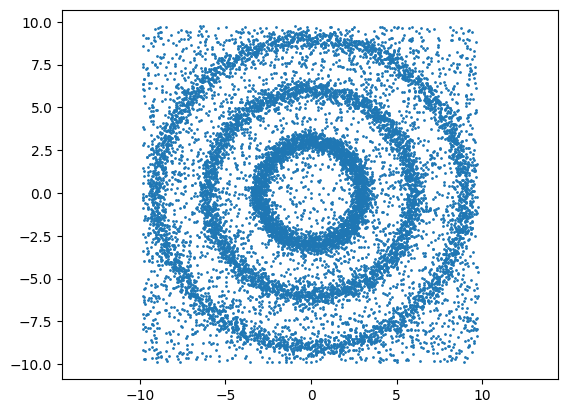

In [2]:
def perturb(x, sigma=0.3, seed=0):
    """
    Adds Gaussian noise to the data.
    :param x: data
    :param sigma: standard deviation of the Gaussian noise
    :param seed: random seed
    :return: noised data
    """
    np.random.seed(seed)
    return x + np.random.normal(0, sigma, size=x.shape)


def add_outliers(x, n_outliers=100, seed=0, scale=1.0, bounding_box=True, r=None):
    """
    Adds uniform noise to the data from an axis aligned box around the data.
    :param x: data
    :param n_outliers: number of outliers
    :param seed: random seed
    :param scale: multiplicative factor for the size of the box relative to the spread of the data.
    :return:
    """

    # assumes zero-centered data
    if r is not None:
        assert isinstance(r, (int, float, complex)) and not isinstance(r, bool) or len(r) == x.shape[-1]
        if isinstance(r, (int, float, complex)) and not isinstance(r, bool):
            mins = -r * np.ones(x.shape[-1])
            maxs = r * np.ones(x.shape[-1])
        else:
            mins = -r
            maxs = r

    else:
        if bounding_box:
            # get mins and maxs of the box
            mins = x.min(axis=0)
            maxs = x.max(axis=0)
            means = (mins + maxs) / 2
            mins = means + (mins - means) * scale
            maxs = means + (maxs - means) * scale
        else:
            # get mins and maxs of the data
            means = x.mean(axis=0)
            l = np.abs(x-means).max()
            mins = -l * scale + means
            maxs = l * scale + means
    np.random.seed(seed)
    outliers = np.random.uniform(mins, maxs, size=(n_outliers, x.shape[1]))
    return np.concatenate([x, outliers])


def generate_data():
    N = 3000
    angles = np.linspace(0,2*np.pi,num=N)

    r1,r2,r3 = 3,6,9
    c1 = np.array([[r1*np.cos(x),r1*np.sin(x)] for x in angles])
    c2 = np.array([[r2*np.cos(x),r2*np.sin(x)] for x in angles])
    c3 = np.array([[r3*np.cos(x),r3*np.sin(x)] for x in angles])
    p = 0.3
    c1,c2,c3 = add_outliers(perturb(c1, p),0), add_outliers(perturb(c2, p), 0), add_outliers(perturb(c3, p), 3900)
    print(c3.shape)
    return np.r_[c1, c2, c3], c3[3000:]

X, outliers = generate_data()
plt.scatter(X[:,0],X[:,1],s=1)
plt.axis('equal')


12900
TOPOGRAPH total: 1.8534951210021973
(1290, 2)


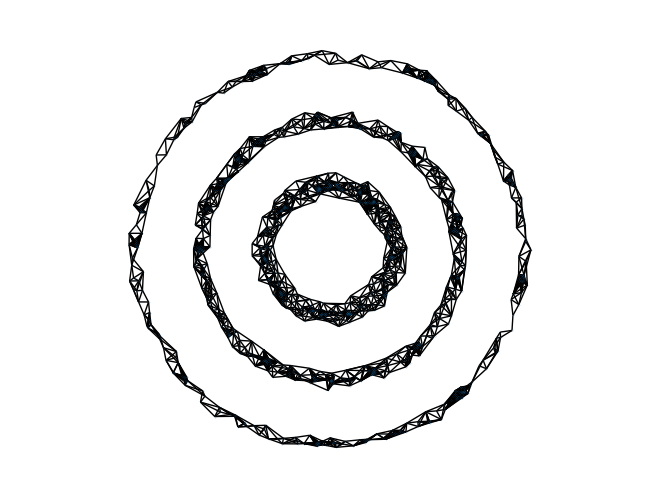

In [3]:
n = X.shape[0]
print(n)
begin = time.time()
k = int(n*0.005)
tg = TOPOGRAPH(dtm_k=k, k=k, n=int(n*0.1))
res = tg.transform(X)
end = time.time()
print(f"TOPOGRAPH total: {end - begin}")
g = res[0]
proj = res[1]
newX = res[-1]
proj_pos = tg.get_pos(newX, proj.toarray())
ori_lap = res[-3]
coarse_lap = res[-2]
print(proj_pos.shape)
nx.draw(g, node_size=0.01, pos=proj_pos)
plt.axis('equal')
plt.show()

end...


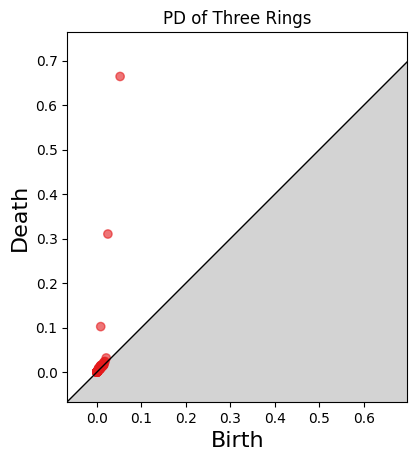

In [4]:
A = nx.to_scipy_sparse_array(g, weight=None)
D = distance.cdist(proj_pos, proj_pos)
D2 = csr_matrix(D).multiply(A)
print("end...")
# Fermat distance, p=2
dm = shortest_path(csgraph=D2.power(2), method='auto')
nor_dis = nor_mat(dm)
PD1 = get_PD(X, max_edge_length=1.1, min_persistence=0, sparse=0.1, use_mat=True, dm=nor_dis)
ax = gd.plot_persistence_diagram(PD1)
ax.set_title("PD of Three Rings")
ax.set_aspect("equal")  # forces to be square shaped
plt.show()